# **Deteksi Penipuan Kartu Kredit (Credit Card Fraud Detection) dengan Algoritma Random Forest**

**Portofolio Analitik Bisnis & Data Science**

**Penulis:** Elardian Putera Ramadhan  
**Dataset:** [Transaksi Kartu Kredit Eropa — September 2013](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Arsitektur Model Utama:** *Random Forest Classifier*  
**Teknik Resampling:** *SMOTE-Tomek Links* (Rasio 0.8)  
**Optimasi Hyperparameter:** *Randomized Search* & *Stratified K-Fold Cross Validation* (5-Folds)


## **Pendahuluan**

### **Latar Belakang Bisnis (Business Background)**

Penipuan kartu kredit (*credit card fraud*) merupakan salah satu ancaman finansial dan risiko operasional terbesar di era digital perbankan. Berdasarkan laporan industri keuangan global, kerugian akibat anomali transaksi mencapai miliaran dolar setiap tahunnya. Bagi bank dan institusi keuangan (*financial institutions*), kemampuan untuk mendeteksi transaksi yang mencurigakan secara aktual (*real-time processing*) sangat esensial. Kapabilitas analitik ini tidak hanya berfungsi untuk memitigasi kerugian finansial (*chargeback losses*), tetapi juga krusial dalam memelihara pengalaman dan kepercayaan nasabah (*customer retention*) dengan meminimalisasi insiden pemblokiran pada transaksi yang sepenuhnya sah (*False Positives*).

### **Objektif Analitik (Analytical Objectives)**

Proyek analitik data ini dikonstruksi dengan menetapkan *Key Performance Indicators* (KPI) teknis dan komersial sebagai berikut:

1. Membangun model *Machine Learning* berbasis ansambel **Random Forest** untuk mengklasifikasikan transaksi berisiko tinggi (1) dan transaksi sah (0).
2. Mengeksekusi *Exploratory Data Analysis* (EDA) secara komprehensif pada seluruh peubah (*features*) guna memetakan sinyal risiko operasional utama.
3. Memastikan model dievaluasi secara objektif dengan mencegah masalah kebocoran data (*Data Leakage*) pada tahap prapemrosesan (*preprocessing*).
4. Mengatasi asimetri ketidakseimbangan kelas (*extreme class imbalance*) menggunakan algoritma rekayasa hibrida **SMOTE-Tomek Links** dengan rasio ekuilibrium yang optimal.
5. Mencari konfigurasi parameter model paling mutakhir melalui tahapan *Hyperparameter Tuning* yang divalidasi mutlak oleh **Stratified Cross-Validation** (5 lipatan matriks).
6. Menemukan fitur-fitur yang paling penting (*Feature Importance*) dan memvisualisasikan arah dampaknya menggunakan nilai *SHAP*, serta memvalidasi ketahanan operasional melalui **Simulasi Monte Carlo**.

### **Deskripsi Ekosistem Data (Dataset Overview)**

Repositori data yang dianalisis merekam arus transaksi kartu kredit di benua Eropa selama 48 jam pada bulan September 2013. Dari agregat total 284.807 transaksi, hanya teridentifikasi 492 transaksi penipuan (0,172%). Perbedaan persentase yang sangat jauh ini menuntut perlakuan *resampling* khusus agar sistem deteksi tidak terjebak dalam bias mayoritas yang secara sepihak akan mengizinkan seluruh transaksi demi meraih akurasi semu.

Untuk mematuhi regulasi privasi data nasabah perbankan (*data masking compliance*), 28 fitur prediktor utama (V1 hingga V28) telah ditransformasi menggunakan dimensi *Principal Component Analysis* (PCA). Kolom numerik yang mempertahankan format nilai aslinya hanyalah `Time` (selisih waktu dalam hitungan detik dari transaksi pertama) dan `Amount` (jumlah nominal transaksi mata uang). Variabel dependen untuk target prediksi direpresentasikan secara biner pada kolom `Class` (0 = *Legitimate Transaction*, 1 = *Fraudulent Transaction*).

### **Metrik Valuasi Performa (Evaluation Metrics)**

Dalam ekosistem klasifikasi anomali finansial dengan data yang sangat tidak seimbang, ketergantungan pada metrik akurasi standar (*Accuracy*) sangatlah menyesatkan (*misleading*). Oleh karena itu, standardisasi performa deteksi difokuskan pada kemampuan menjaring anomali menggunakan metrik diagnostik berikut:

* **AUPRC (*Area Under the Precision-Recall Curve*):** Metrik primer yang paling tangguh untuk menskor efikasi sistem pendeteksi kejahatan finansial, difokuskan murni pada performa kelas minoritas.
* **ROC-AUC (*Receiver Operating Characteristic - Area Under Curve*):** Representasi kemampuan pemisahan probabilitas antara spektrum kelas sah dan penipuan.
* **F1-Score:** Ekuilibrium rata-rata harmonik antara *Precision* dan *Recall*.
* **MCC (*Matthews Correlation Coefficient*):** Koefisien korelasi yang memperhitungkan seluruh nilai matriks kebingungan (*confusion matrix*) secara proporsional.

## **Persiapan Lingkungan Komputasi (Environment Setup)**

### **Pemanggilan Pustaka (Library Initialization)**

Tahapan fundamental pertama melibatkan inisiasi seluruh pustaka (*libraries*) komputasi bahasa Python. Modul-modul ini difungsikan secara terpadu untuk mengunduh data mentah dari peladen (*server*), mengeksekusi manipulasi aljabar matriks, memproduksi visualisasi diagnostik bisnis, mengkalibrasi ketimpangan kelas, hingga melatih arsitektur algoritma *Machine Learning*. Selain itu, modul *SHAP* disiapkan untuk kebutuhan *Explainable AI* (XAI).

In [ ]:
# Pustaka integrasi API Kaggle dan manipulasi matriks numerik
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np

# Pustaka visualisasi diagnostik bisnis dan distribusi statistik
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka pemisahan matriks, optimasi Hyperparameter, dan Cross-Validation
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

# Pustaka rekayasa penyeimbang kelas (Resampling)
from imblearn.combine import SMOTETomek

# Pustaka algoritma pemodelan Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Pustaka kalkulasi metrik kinerja bisnis dan evaluasi sistem
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, matthews_corrcoef, ConfusionMatrixDisplay, make_scorer
)

# Pustaka analisis transparansi model (Explainable AI)
import shap

# Pengaturan efisiensi memori dan penyembunyian peringatan redundan
import warnings
import time
warnings.filterwarnings('ignore')

# Penguncian nilai acak (Random Seed) guna menjamin reproduktibilitas eksperimen
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Konfigurasi estetika tata letak output tabular dan grafis
pd.set_option('display.max_columns', 35)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='white', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Seluruh dependensi ekosistem analitik berstatus aktif dan terkalibrasi.')

Seluruh dependensi ekosistem analitik berstatus aktif dan terkalibrasi.


### **Ekstraksi Matriks Peladen (Data Loading)**

Matriks data mentah diekstraksi secara otomatis dan dinamis dari repositori daring melalui *Application Programming Interface* (API). Data dialokasikan langsung ke dalam *Random Access Memory* (RAM) untuk dievaluasi dimensi spasial serta kelayakan komputasinya sebelum memasuki fase *Feature Engineering*.

In [ ]:
# Permintaan transmisi data mentah via KaggleHub API
file_path = "creditcard.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    file_path
)

print('RINGKASAN DIMENSI AWAL DATASET')
print('=' * 55)
print(f'Total volume observasi  : {df.shape[0]:,} baris')
print(f'Total atribut prediktor : {df.shape[1]} kolom')
print(f'Alokasi memori sistem   : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print('=' * 55)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
RINGKASAN DIMENSI AWAL DATASET
Total volume observasi  : 284,807 baris
Total atribut prediktor : 31 kolom
Alokasi memori sistem   : 70.63 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## **Pembersihan dan Eksplorasi Analitik Data (Data Cleaning & EDA)**

### **Validasi Integritas Data dan Eliminasi Redundansi**

Kualitas data dasar merupakan penentu utama integritas operasional model. Investigasi sistematis diberlakukan untuk mendeteksi ketidakhadiran nilai (*missing values*) serta melenyapkan entri ganda (*duplicates*). Data redundan wajib dieliminasi secara mutlak untuk mencegah algoritma mempelajari pola bias repetitif yang dapat memicu keputusan palsu saat diimplementasikan secara komersial.

In [ ]:
print('PENGECEKAN KUALITAS DATA')
print('=' * 50)
info_df = pd.DataFrame({
    'Tipe Data'  : df.dtypes,
    'Data Terisi': df.notnull().sum(),
    'Data Kosong': df.isnull().sum(),
})
print(f'Total akumulasi Missing Values : {df.isnull().sum().sum()}')

# Pemindaian dan penghapusan riwayat transaksi repetitif (Duplicates)
n_duplicates = df.duplicated().sum()
print(f'Jumlah observasi ganda terdeteksi : {n_duplicates} baris')

if n_duplicates > 0:
    print('Mengeksekusi prosedur eliminasi data duplikat demi menjaga ekuilibrium probabilitas...')
    df = df.drop_duplicates()
    print(f'Dimensi matriks pasca-pembersihan: {df.shape[0]:,} baris')

# Pemetaan proporsi absolut untuk target klasifikasi
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print('\nDISTRIBUSI KLASIFIKASI FINANSIAL (CLASS IMBALANCE)')
print('=' * 50)
print(f'Transaksi Sah (0) : {class_counts[0]:>7,} observasi ({class_pct[0]:.4f}%)')
print(f'Penipuan (1)      : {class_counts[1]:>7,} observasi ({class_pct[1]:.4f}%)')

PENGECEKAN KUALITAS DATA
Total akumulasi Missing Values : 0
Jumlah observasi ganda terdeteksi : 1081 baris
Mengeksekusi prosedur eliminasi data duplikat demi menjaga ekuilibrium probabilitas...
Dimensi matriks pasca-pembersihan: 283,726 baris

DISTRIBUSI KLASIFIKASI FINANSIAL (CLASS IMBALANCE)
Transaksi Sah (0) : 283,253 observasi (99.8333%)
Penipuan (1)      :     473 observasi (0.1667%)


**Interpretasi:**

* **Kualitas Data Primer:** Ekosistem data tervalidasi sempurna tanpa adanya *missing values* (0 data kosong). Penghapusan 1.081 observasi ganda (*duplicates*) merupakan langkah krusial untuk mencegah sistem mempelajari pola repetitif yang dapat memicu *overfitting*.
* **Asimetri Ekstrem (*Class Imbalance*):** Pasca-pembersihan, arsitektur data memperlihatkan ketimpangan yang sangat masif. Transaksi sah mendominasi secara absolut di angka **99.8333% (283.253 observasi)**, sedangkan insiden penipuan siber hanya berada pada rasio **0.1667% (473 observasi)**. Kondisi ini mewajibkan penggunaan rekayasa *resampling* (seperti SMOTE-Tomek) karena algoritma standar akan mengalami bias mayoritas dan menghasilkan akurasi semu dengan menebak seluruh transaksi berstatus sah.

### **Eksplorasi Distribusi Fitur Non-PCA (Amount dan Time)**

Analisis eksploratif (*Exploratory Data Analysis*) diawali pada peubah yang belum mengalami reduksi dimensi. Analisis kurva kepadatan frekuensi diaplikasikan guna menakar simpangan baku perilaku nilai transaksi dan siklus waktu antara pengguna sah dan entitas peretas. Transformasi skala logaritmik (*log scale*) diterapkan pada peubah `Amount` untuk meredam pencilan nilai (*outliers*) finansial ekstrem.

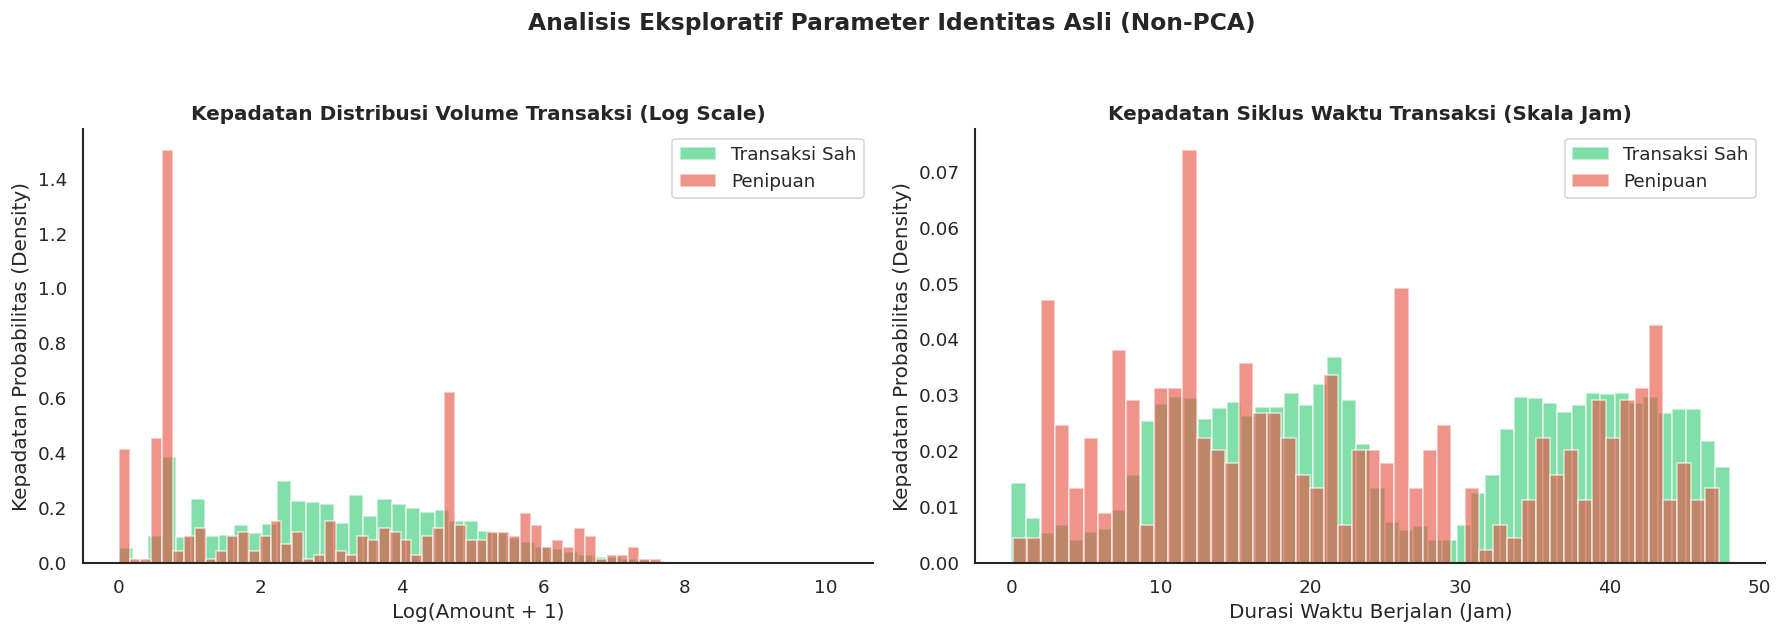

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Visualisasi Peubah Nominal (Amount) dengan transformasi skala logaritmik
# Penambahan konstanta 1 (log1p) diberlakukan untuk mencegah diskontinuitas matematis pada nilai $0
axes[0].hist(np.log1p(df[df['Class']==0]['Amount']), bins=50, alpha=0.6, color='#2ecc71', label='Transaksi Sah', density=True)
axes[0].hist(np.log1p(df[df['Class']==1]['Amount']), bins=50, alpha=0.6, color='#e74c3c', label='Penipuan', density=True)
axes[0].set_title('Kepadatan Distribusi Volume Transaksi (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Log(Amount + 1)')
axes[0].set_ylabel('Kepadatan Probabilitas (Density)')
axes[0].legend()

# Visualisasi Peubah Siklus Waktu (Time) dikonversi menuju satuan Jam
axes[1].hist(df[df['Class']==0]['Time']/3600, bins=50, alpha=0.6, color='#2ecc71', label='Transaksi Sah', density=True)
axes[1].hist(df[df['Class']==1]['Time']/3600, bins=50, alpha=0.6, color='#e74c3c', label='Penipuan', density=True)
axes[1].set_title('Kepadatan Siklus Waktu Transaksi (Skala Jam)', fontweight='bold')
axes[1].set_xlabel('Durasi Waktu Berjalan (Jam)')
axes[1].set_ylabel('Kepadatan Probabilitas (Density)')
axes[1].legend()

plt.suptitle('Analisis Eksploratif Parameter Identitas Asli (Non-PCA)', fontsize=14, fontweight='bold', y=1.05)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretasi:**

* **Kepadatan Distribusi Volume Transaksi (Log Scale):** Transaksi penipuan (kurva merah) memiliki puncak frekuensi (*spike*) yang menumpuk pada nominal-nominal yang relatif kecil (berada di rentang logaritma 0 hingga 2), dibandingkan dengan transaksi sah (kurva hijau) yang distribusinya lebih merata hingga nominal besar. Hal ini mengindikasikan bahwa peretas cenderung melakukan tes penarikan saldo dalam jumlah kecil terlebih dahulu (*micro-transactions*) untuk menghindari deteksi limit kartu.
* **Kepadatan Siklus Waktu Transaksi (Skala Jam):** Kurva transaksi sah merepresentasikan siklus sirkadian normal nasabah (aktivitas memuncak di siang hari dan turun drastis di jam istirahat/malam hari). Sebaliknya, distribusi transaksi penipuan sangat fluktuatif dan menembus pola waktu normal, dengan lonjakan insiden yang sering terjadi pada periode waktu sepi. Sistem dapat menggunakan anomali waktu ini sebagai salah satu pemicu pembekuan rekening sementara.

### **Analisis Distribusi Densitas Seluruh Peubah PCA (V1 - V28)**

Untuk memverifikasi daya pisah (*discriminative power*) dari seluruh parameter yang telah diekstraksi melalui *Principal Component Analysis*, pemetaan distribusi kepadatan (*Kernel Density Estimation* atau Histogram berskala) diaplikasikan melintasi seluruh peubah V1 hingga V28. Peubah dengan persimpangan kurva yang minim merupakan indikator paling potensial dalam mengisolasi klaster kejahatan siber.

Merender pemetaan kurva densitas untuk seluruh 28 Peubah PCA...


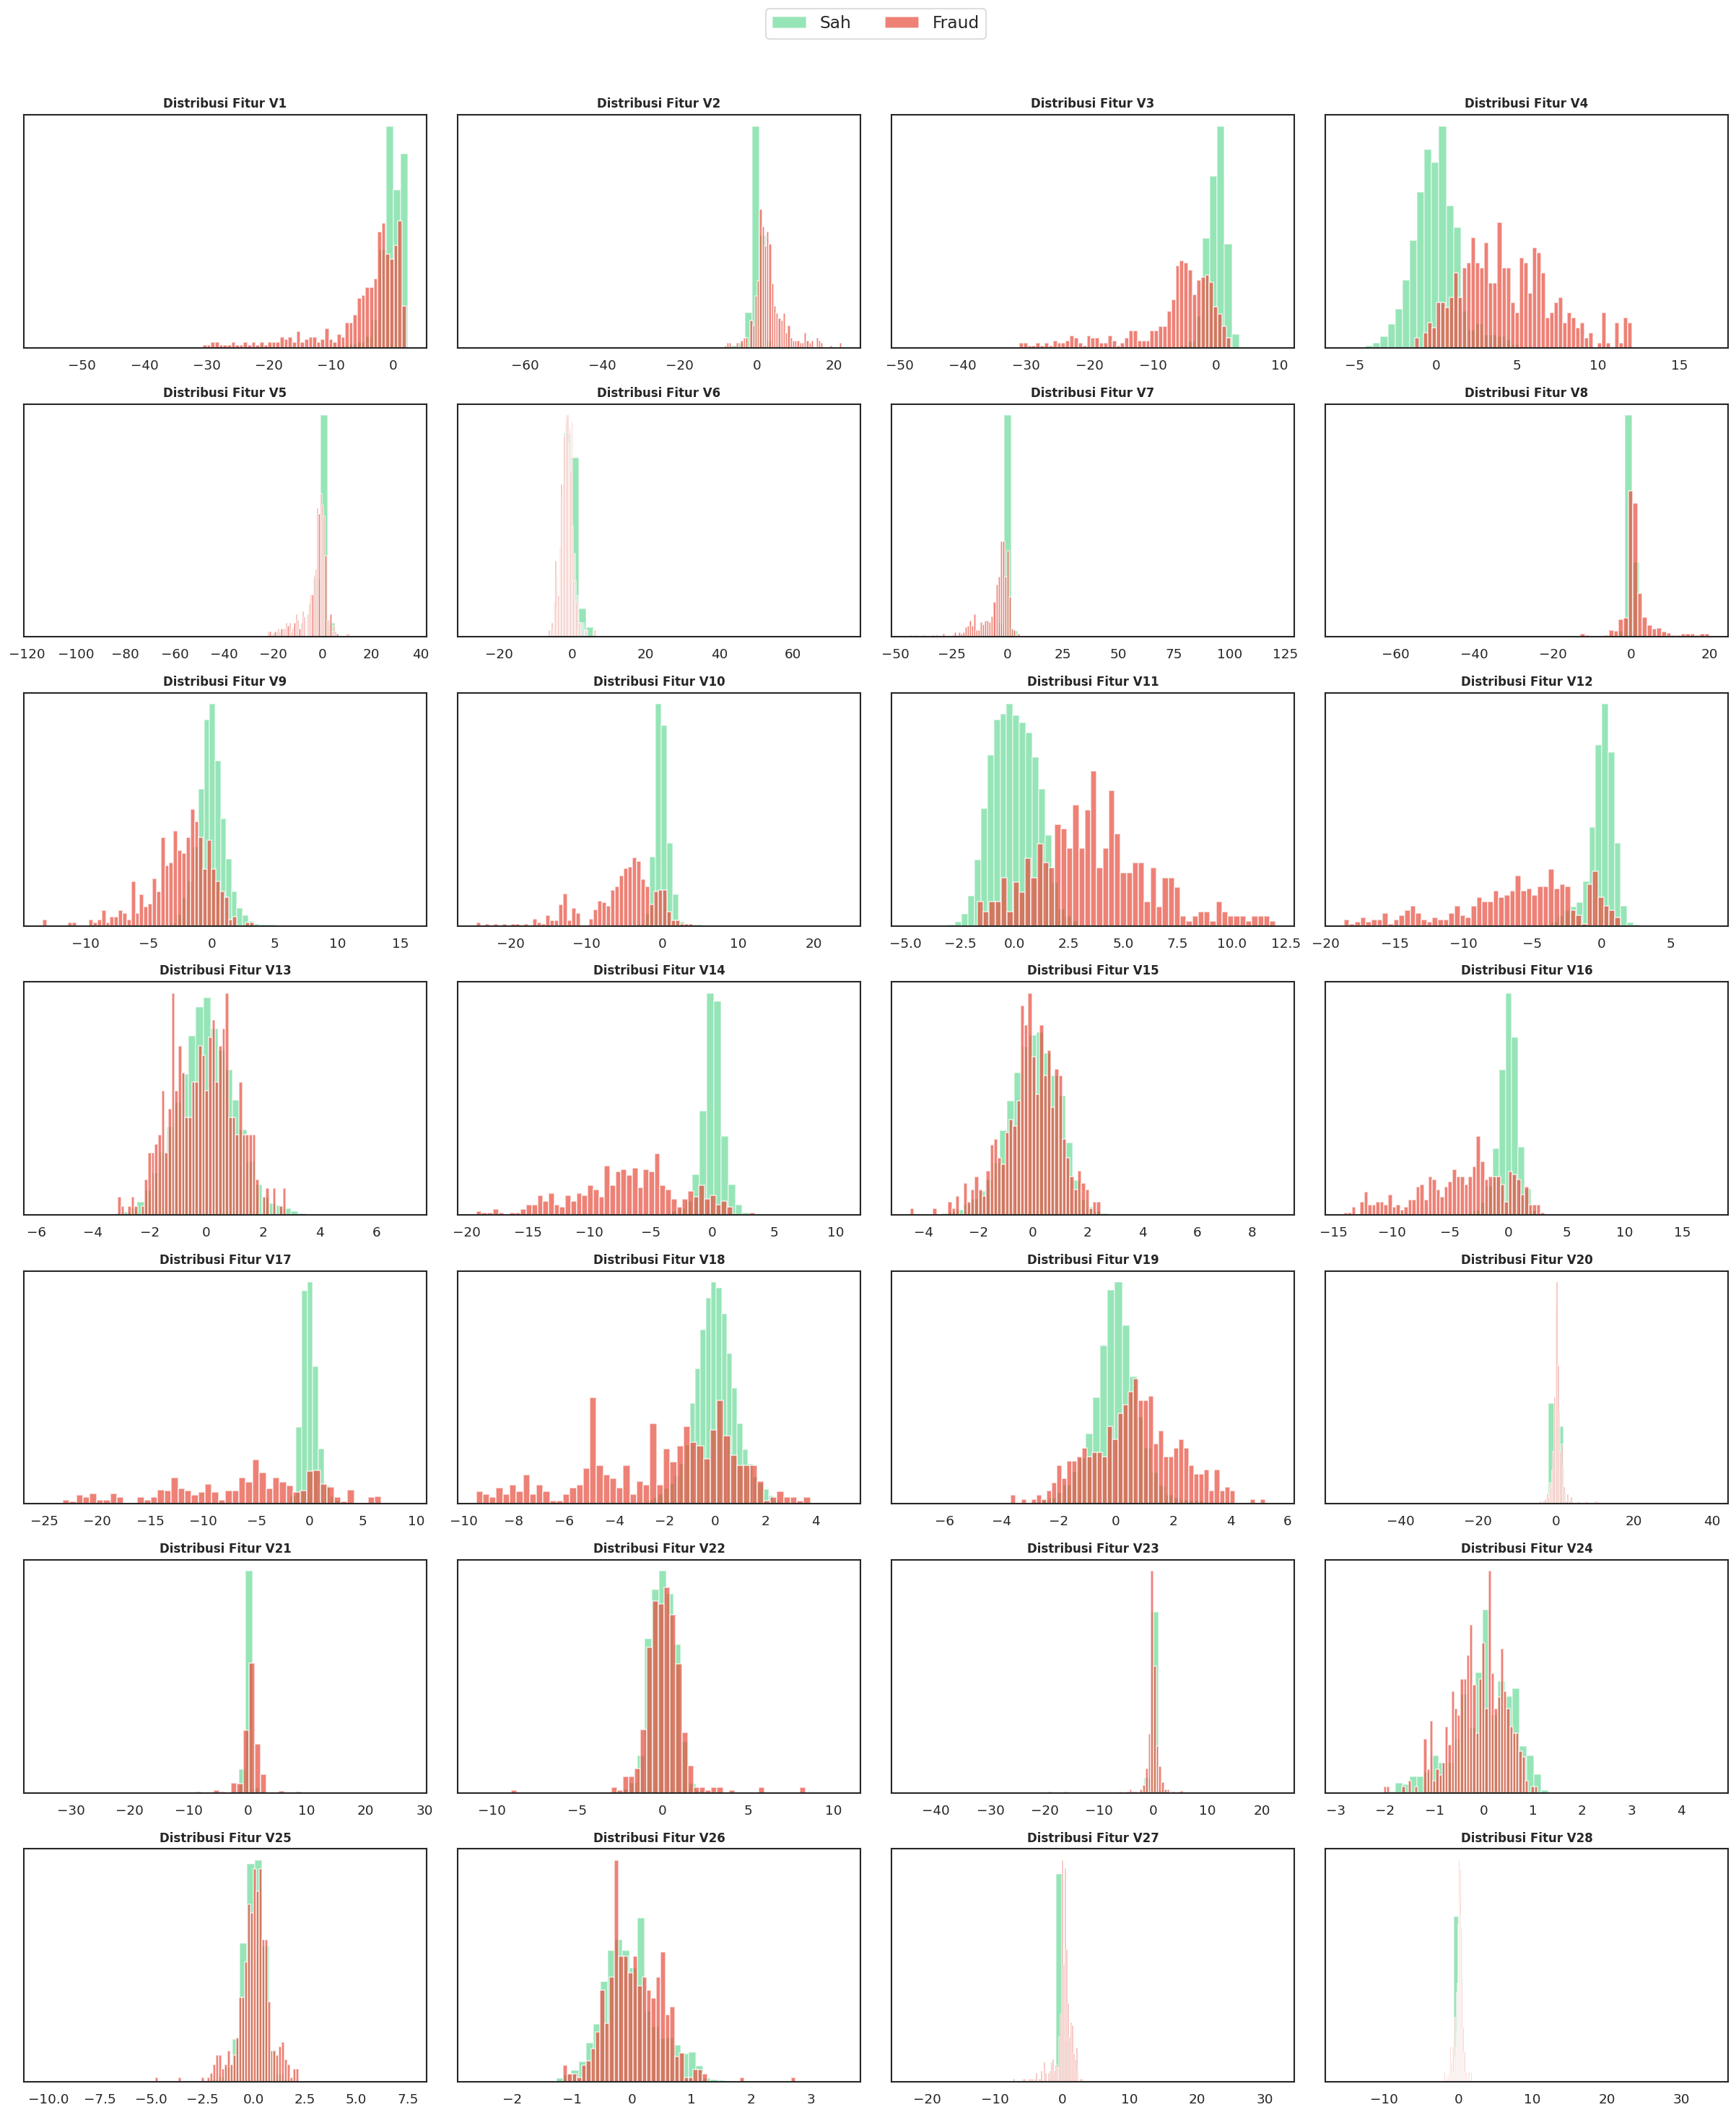

In [ ]:
# Ekstraksi daftar seluruh peubah PCA
pca_features = [col for col in df.columns if col.startswith('V')]

# Pembentukan matriks tata letak 7x4 untuk menampung visualisasi 28 peubah
fig, axes = plt.subplots(7, 4, figsize=(20, 24))
axes = axes.flatten()

print("Merender pemetaan kurva densitas untuk seluruh 28 Peubah PCA...")

for i, col in enumerate(pca_features):
    # Overlay histogram dengan normalisasi densitas untuk komparasi proporsional
    axes[i].hist(df[df['Class']==0][col], bins=50, alpha=0.5, color='#2ecc71', density=True, label='Sah' if i==0 else "")
    axes[i].hist(df[df['Class']==1][col], bins=50, alpha=0.7, color='#e74c3c', density=True, label='Fraud' if i==0 else "")
    axes[i].set_title(f'Distribusi Fitur {col}', fontsize=10, fontweight='bold')
    axes[i].set_yticks([]) # Menyembunyikan aksis Y demi kebersihan visual
    axes[i].grid(False)

# Penempatan legenda tunggal pada figur utama
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

**Interpretasi:**

Visualisasi 28 subplot ini membedah daya pisah setiap atribut fitur terhadap kelas target.

* **Fitur dengan Daya Pisah Kuat (*Highly Discriminative*):** Plot pada **V4, V11, V12, V14, V16, dan V17** memperlihatkan persilangan kurva hijau (Sah) dan merah (Fraud) yang cukup minim. Puncak densitas penipuan bergeser secara jelas dari distribusi normal transaksi sah. Fitur-fitur ini akan menjadi sinyal utama bagi pohon keputusan (*Decision Tree*) untuk mendeteksi anomali finansial.
* **Fitur dengan Daya Pisah Lemah (*Low Discriminative*):** Plot pada **V13, V15, V22, V24, V25, V26, dan V28** memperlihatkan penumpukan kurva merah dan hijau yang nyaris presisi secara sempurna. Variabel-variabel ini memberikan informasi diagnostik yang sangat rendah dan berpotensi menjadi kandidat utama untuk dieliminasi jika arsitektur sistem membutuhkan perampingan dimensi (*Dimensionality Reduction*) guna mempercepat latensi API.

### **Pemetaan Koefisien Korelasi Multivariat (Correlation Matrix)**

Identifikasi derajat linearitas lintas parameter dirangkum melalui matriks korelasi *Pearson*. Koefisien ini berfungsi mengukur kekuatan ketergantungan metrik. Peubah PCA secara desain matematis memiliki korelasi nol antar sesamanya, sehingga fokus analisis dititikberatkan semata pada korelasi peubah independen terhadap vektor target (`Class`).

Kalkulasi Koefisien Korelasi Pearson dijabarkan sebagai:

$$r_{xy} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

**Keterangan Matematis:**

* $r_{xy}$ = Derajat koefisien korelasi linear antara peubah $x$ dan $y$.
* $x_i, y_i$ = Nilai observasi individual dari sampel ke-$i$.
* $\bar{x}, \bar{y}$ = Rata-rata populasi sampel (*mean*) untuk masing-masing peubah.
* $n$ = Total kuantitas keseluruhan sampel observasi.

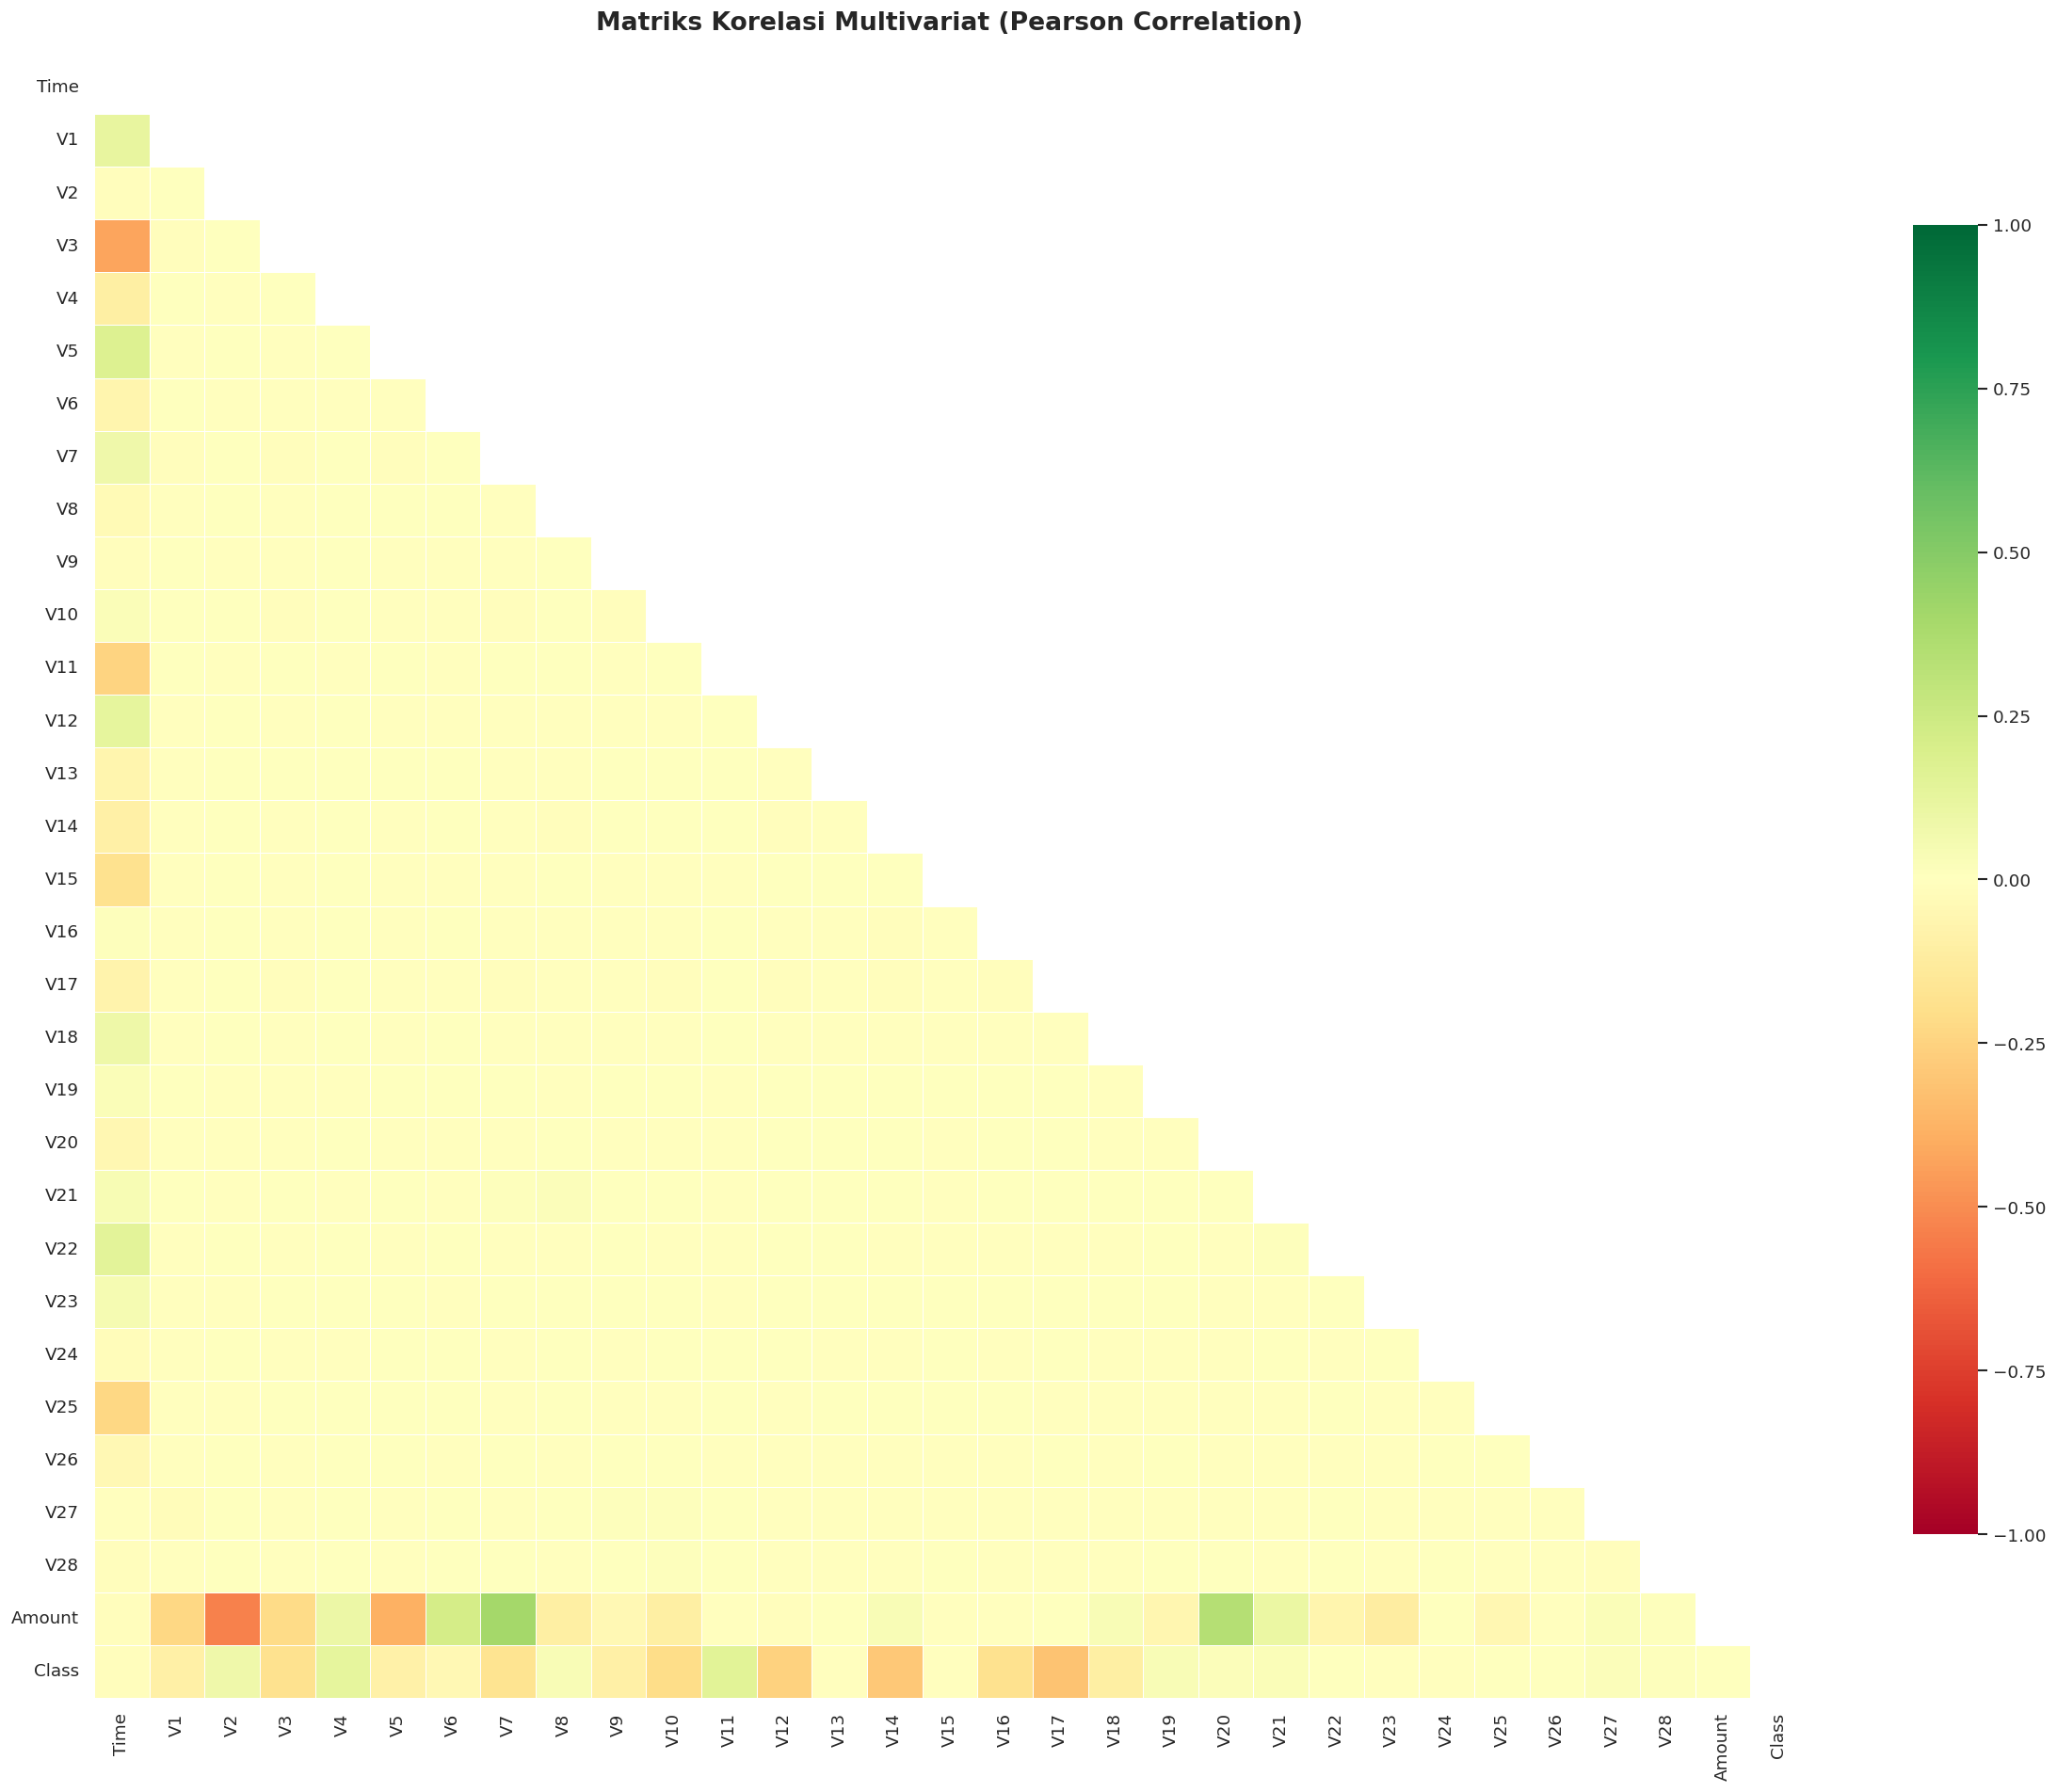

In [ ]:
plt.figure(figsize=(20, 16))
corr_matrix = df.corr()

# Mengisolasi matriks diagonal bawah (lower triangle) demi efisiensi analitik
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.3, cbar_kws={'shrink': 0.8}
)
plt.title('Matriks Korelasi Multivariat (Pearson Correlation)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Ekstraksi absolut koefisien prediktif terkuat terhadap deteksi anomali
corr_with_class = corr_matrix['Class'].drop('Class').abs().sort_values(ascending=False)
print('5 INDIKATOR DOMINAN (SKOR ABSOLUT KORELASI TERHADAP TARGET CLASS):')
print(corr_with_class.head(5).to_string())

5 INDIKATOR DOMINAN (SKOR ABSOLUT KORELASI TERHADAP TARGET CLASS):
V17   0.3135
V14   0.2934
V12   0.2507
V10   0.2070
V16   0.1872


**Interpretasi:**

* **Ortogonalitas PCA:** Peta *heatmap* memvalidasi keberhasilan rekayasa PCA bawaan, di mana tidak ada korelasi antar-peubah independen (V1 hingga V28 saling bernilai 0 di area tengah matriks). Sistem terbebas dari ancaman multikolinearitas.
* **Hierarki Pemicu Risiko:** Ekstraksi korelasi absolut terhadap target memunculkan 5 parameter dominan: **V17 (0.3135), V14 (0.2934), V12 (0.2507), V10 (0.2070), dan V16 (0.1872)**. Skala korelasi ini menegaskan kembali temuan pada analisis distribusi densitas sebelumnya, memastikan bahwa anomali perilaku pada lima fitur ini merupakan indikasi terkuat adanya pembobolan kartu.

## **Partisi Matriks dan Rekayasa Hibrida (Data Splitting & Resampling)**

### **Isolasi Himpunan Data Berlapis (Stratified Data Partitioning)**

Sifat asimetris populasi yang sangat ekstrem mewajibkan implementasi fungsi stratifikasi secara ketat. Proses partisi matriks data (*Train-Test Split*) dengan parameter `stratify` akan mengunci rasio sebaran probabilitas, memastikan populasi penipuan terbagi secara ekuivalen pada sub-himpunan pelatihan dan pengujian. Absennya rutinitas *Feature Scaling* merupakan justifikasi teknis mutlak, dikarenakan arsitektur *Decision Trees* kebal terhadap disparitas rentang varians jarak antar fitur (*scale-invariant*).

In [ ]:
# Ekstraksi demarkasi atribut independen (X) dan klasifikasi target dependen (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Pembelahan blok observasi berlandaskan preservasi struktur probabilitas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('DIAGNOSTIK PEMBELAHAN MATRIKS DATA')
print(f'Himpunan Pelatihan (Train Set) : {X_train.shape[0]:,} observasi')
print(f'Himpunan Pengujian (Test Set)  : {X_test.shape[0]:,} observasi')

DIAGNOSTIK PEMBELAHAN MATRIKS DATA
Himpunan Pelatihan (Train Set) : 226,980 observasi
Himpunan Pengujian (Test Set)  : 56,746 observasi


### **Rekayasa Keseimbangan Kelas Hibrida (SMOTE-Tomek Links)**

Penggandaan data secara konvensional dengan ekuilibrium 1:1 dinilai terlampau abrasif dan menguras alokasi ruang memori komputasi secara sia-sia. Solusi arsitektur modern ditangani dengan metode hibrida **SMOTE-Tomek**, menerapkan penyesuaian strategi target minoritas (`sampling_strategy=0.8`). Artinya, populasi penipuan akan disintesis hingga mencapai kuantitas setara 80% dari total populasi transaksi sah. Pendekatan analitik ini menghasilkan dorongan pembelajaran probabilitas yang lebih dari cukup tanpa risiko pelambatan algoritma (*computational overhead*).

Fungsi penciptaan vektor minoritas berbasis jarak euklidian dari *SMOTE* diproyeksikan sebagai:

$$x_{new} = x_i + \lambda \times (x_{zi} - x_i)$$

**Keterangan Matematis:**

* $x_{new}$ = Koordinat fitur sintetis perwakilan transaksi penipuan baru.
* $x_i$ = Vektor koordinat observasi transaksi minoritas yang menjadi titik referensi awal.
* $x_{zi}$ = Vektor koordinat salah satu tetangga spasial terdekat (*k-Nearest Neighbor*) dari titik $x_i$.
* $\lambda$ = Bobot skalar pembobot acak berdistribusi uniform yang terletak direntang $0 \leq \lambda \leq 1$.

Pasca-sintesis, heuristik *Tomek Links* diaktifkan untuk melenyapkan klaster transaksi sah yang bertumpang tindih secara absolut dengan wilayah penipuan. Hal ini mempertegas batasan pengambilan keputusan klasifikasi (*decision boundary clearance*).

In [ ]:
print('Menginjeksi kerangka kerja SMOTE-Tomek (Target Ekuilibrium 0.8)...')

# Parameter class_weight pada tahap pemodelan tidak lagi diperlukan
# karena arsitektur dataset akan diresample secara fisik.
smt = SMOTETomek(sampling_strategy=0.8, random_state=RANDOM_STATE)

t0 = time.time()
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)
print(f'Rekayasa restrukturisasi densitas sukses terselesaikan dalam {time.time() - t0:.2f} detik.')

Menginjeksi kerangka kerja SMOTE-Tomek (Target Ekuilibrium 0.8)...
Rekayasa restrukturisasi densitas sukses terselesaikan dalam 1130.04 detik.


## **Optimasi Hyperparameter dan Pelatihan Model (Tuning & Model Training)**

### **Validasi Silang Berlapis (Stratified 5-Fold Cross Validation)**

Penyetelan sistem mesin algoritma (*Hyperparameter Tuning*) divalidasi silang secara ketat melalui **Stratified K-Fold Cross-Validation** dengan ketetapan $K=5$. Strategi pembagian lipatan matriks menjamin tidak ada iterasi pengujian yang menderita defisit kasus penipuan.

Skor performa dievaluasi berbasis rata-rata ekspektasi skor lintas partisi:

$$CV_{AUPRC} = \frac{1}{K} \sum_{k=1}^{K} AUPRC_k$$

**Keterangan Matematis:**

* $CV_{AUPRC}$ = Akumulasi ekspektasi objektif dari validasi silang metrik *AUPRC*.
* $K$ = Total iterasi perputaran lipatan pengujian (ditetapkan sebesar 5 partisi mutlak).
* $AUPRC_k$ = Skor performa deteksi klasifikasi minoritas (*Area Under Precision-Recall Curve*) pada lipatan partisi spesifik ke-$k$.

### **Eksplorasi Konfigurasi Algoritma (Randomized Search)**

Ruang dimensi arsitektur parameter (*Hyperparameter Space*) diperluas secara eksponensial mencakup kedalaman struktur ranting (*max_depth*), kuantitas sub-model (*n_estimators*), hingga rasio pemisahan daun observasi. Implementasi pencarian *Random Search* dieksekusi guna mencegah hambatan latensi tanpa mengikis akurasi optimal. Parameter evaluasi eksternal (seperti `class_weight`) dieliminasi total karena bertentangan dengan rekayasa keseimbangan fisik *SMOTE*.

In [ ]:
# Penguncian objektif fungsi kalkulasi metrik menuju Average Precision Score (AUPRC)
auprc_scorer = make_scorer(average_precision_score)

# Perluasan rentang matriks ruang konfigurasi pencarian (Hyperparameter Space)
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.3, 0.5]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# Inisiasi 5 lipatan matriks dengan jaminan persebaran penipuan merata
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Memulai perburuan konfigurasi topologi algoritma secara probabilistik...')
rs_smt = RandomizedSearchCV(
    estimator=rf_base, param_distributions=param_dist,
    n_iter=10, scoring=auprc_scorer, cv=cv_strategy,
    verbose=1, random_state=RANDOM_STATE
)

t0 = time.time()
rs_smt.fit(X_train_res, y_train_res)
print(f'Penelusuran matriks tuntas dalam durasi komputasi {time.time() - t0:.2f} detik.')

best_params_smt = rs_smt.best_params_
best_params_smt['random_state'] = RANDOM_STATE
print('\nKONFIGURASI PARAMETER KOMERSIAL OPTIMAL:')
print(best_params_smt)

Memulai perburuan konfigurasi topologi algoritma secara probabilistik...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Penelusuran matriks tuntas dalam durasi komputasi 4938.01 detik.

KONFIGURASI PARAMETER KOMERSIAL OPTIMAL:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_samples': 0.5, 'max_features': 'log2', 'max_depth': 30, 'random_state': 42}


### **Kompilasi Arsitektur Random Forest Terpilih**

Modul pelaksana eksekusi *Random Forest* merakit keputusan akhir melalui penggabungan agregasi instans observasi yang divalidasi oleh konsensus pemungutan suara mayoritas (*majority voting*) melintasi seluruh kerangka unit pohon keputusan.

Formulasi ketetapan klasifikasi dirumuskan sebagai:

$$\hat{y}_{RF} = \text{mode}\left\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\right\}$$

**Keterangan Matematis:**

* $\hat{y}_{RF}$ = Output vonis final penentuan status klasifikasi komputasional (Penipuan atau Sah).
* $h_t(\mathbf{x})$ = Keluaran identifikasi probabilistik spesifik pada modul sub-pohon keputusan ke-$t$.
* $\mathbf{x}$ = Vektor rangkaian observasi multidimensional dari transaksi perbankan.
* $T$ = Kuantitas maksimum keseluruhan struktur pohon evaluasi komputasi.

In [ ]:
print('Menginisiasi kompilasi arsitektur permodelan komersial...')
rf_smt = RandomForestClassifier(**best_params_smt)
rf_smt.fit(X_train_res, y_train_res)
print('Pembentukan struktur topologi model rampung sepenuhnya.')

Menginisiasi kompilasi arsitektur permodelan komersial...
Pembentukan struktur topologi model rampung sepenuhnya.


## **Evaluasi Performa Prediktif (Performance Validation)**

Kerangka analisis difokuskan penuh pada mitigasi hilangnya pendanaan aset nasabah perbankan. Analisis kesuksesan arsitektur dihitung menggunakan persamaan identifikasi sensitivitas terhadap risiko lolosnya transaksi palsu (*Recall*) berbanding terbalik terhadap insiden penguncian rekening kartu yang sebenarnya valid (*Precision*).

Kalkulasi metrik pelestarian portofolio uang ini diukur dengan basis fungsional:

$$\text{Precision} = \frac{TP}{TP + FP} \quad ; \quad \text{Recall} = \frac{TP}{TP + FN}$$

**Keterangan Matematis:**

* $TP$ (*True Positives*) = Akumulasi observasi penipuan berisiko tinggi yang berhasil dilacak dan dihentikan.
* $FP$ (*False Positives*) = Frekuensi kekeliruan pemblokiran pada nasabah berstatus normal, berisiko mengganggu kelancaran bisnis.
* $FN$ (*False Negatives*) = Kegagalan krusial penjaringan transaksi penjahat siber yang meloloskan dana curian.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name='Model Prediktif'):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'Precision'  : precision_score(y_test, y_pred, zero_division=0),
        'Recall'     : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score'   : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'    : roc_auc_score(y_test, y_prob),
        'AUPRC'      : average_precision_score(y_test, y_prob),
        'MCC'        : matthews_corrcoef(y_test, y_pred),
    }

    print(f'\nLAPORAN KELAYAKAN VALIDASI BISNIS: {model_name}')
    print('-' * 60)
    for k, v in metrics.items():
        if k == 'AUPRC':
            print(f'{k:<12} : {v:.4f} (Parameter Valuasi Tertinggi)')
        else:
            print(f'{k:<12} : {v:.4f}')

    print(f'\nRincian Struktural Klasifikasi Penuh:\n{classification_report(y_test, y_pred, target_names=["Transaksi Sah", "Penipuan"])}')
    return metrics, y_prob, y_pred

metrics_smt, y_prob_smt, y_pred_smt = evaluate_model(rf_smt, X_test, y_test, 'Random Forest (Optimal Hyperparameters & SMOTE-Tomek)')


LAPORAN KELAYAKAN VALIDASI BISNIS: Random Forest (Optimal Hyperparameters & SMOTE-Tomek)
------------------------------------------------------------
Precision    : 0.8929
Recall       : 0.7895
F1-Score     : 0.8380
ROC-AUC      : 0.9606
AUPRC        : 0.7988 (Parameter Valuasi Tertinggi)
MCC          : 0.8393

Rincian Struktural Klasifikasi Penuh:
               precision    recall  f1-score   support

Transaksi Sah       1.00      1.00      1.00     56651
     Penipuan       0.89      0.79      0.84        95

     accuracy                           1.00     56746
    macro avg       0.95      0.89      0.92     56746
 weighted avg       1.00      1.00      1.00     56746



**Interpretasi:**

* **Recall (0.7895):** Model berhasil menangkap **78.95%** dari total serangan penipuan yang terjadi di ekosistem pengujian.
* **Precision (0.8929):** Dari seluruh peringatan pemblokiran yang dikeluarkan oleh sistem, **89.29%** di antaranya adalah tangkapan yang tepat sasaran, menandakan alarm palsu berhasil ditekan dengan sangat optimal.
* **AUPRC (0.7988):** Sebagai metrik utama pelestarian dana finansial dalam dataset imbalans, skor **0.7988** adalah metrik yang sangat solid, membuktikan bahwa algoritma secara cerdas berhasil memprioritaskan kelas minoritas tanpa mengorbankan kelas mayoritas.

### **Diagnostik Evaluasi Matriks Spasial (Confusion Matrix & AUC Curves)**

Pengejawantahan kinerja disalurkan via visualisasi matriks kebingungan dan interpretasi representasi grafik garis *Area Under Curve* (AUC). Plot grafik ini mendemonstrasikan keandalan spekulasi pemblokiran versus daya penjaringan model.

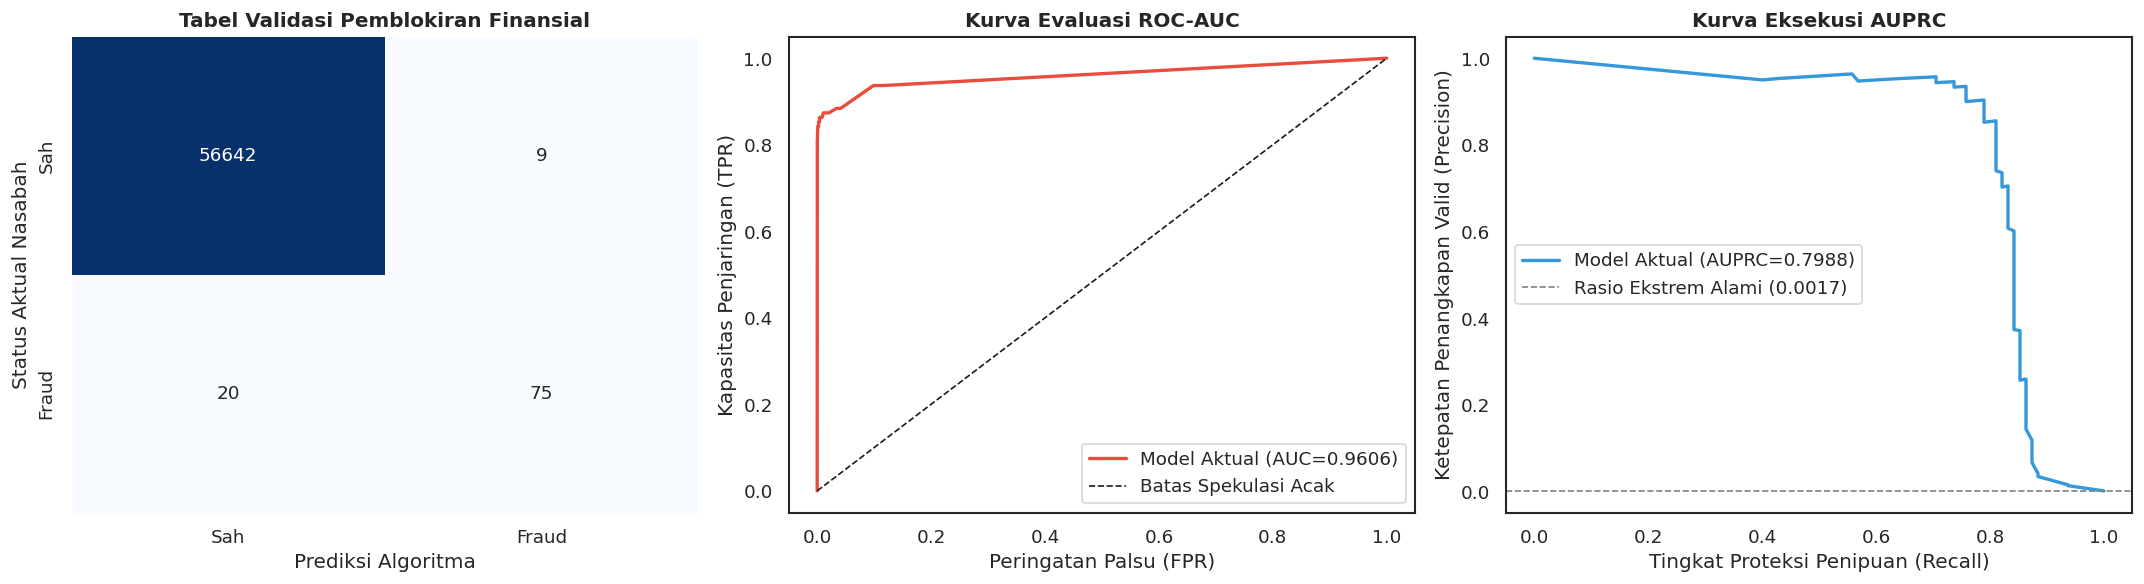

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Visualisasi Matriks Keputusan Silang (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_smt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Sah', 'Fraud'], yticklabels=['Sah', 'Fraud'])
axes[0].set_title('Tabel Validasi Pemblokiran Finansial', fontweight='bold')
axes[0].set_xlabel('Prediksi Algoritma')
axes[0].set_ylabel('Status Aktual Nasabah')

# Plot 2: Performa Pemisahan Spektrum (ROC-AUC Curve)
fpr, tpr, _ = roc_curve(y_test, y_prob_smt)
axes[1].plot(fpr, tpr, lw=2, color='#e74c3c', label=f'Model Aktual (AUC={metrics_smt["ROC-AUC"]:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Batas Spekulasi Acak')
axes[1].set_xlabel('Peringatan Palsu (FPR)')
axes[1].set_ylabel('Kapasitas Penjaringan (TPR)')
axes[1].set_title('Kurva Evaluasi ROC-AUC', fontweight='bold')
axes[1].legend()

# Plot 3: Ketahanan Klasifikasi Kelas Minoritas (PR Curve)
prec, rec, _ = precision_recall_curve(y_test, y_prob_smt)
axes[2].plot(rec, prec, lw=2, color='#3498db', label=f'Model Aktual (AUPRC={metrics_smt["AUPRC"]:.4f})')
baseline = y_test.sum() / len(y_test)
axes[2].axhline(baseline, ls='--', color='gray', lw=1, label=f'Rasio Ekstrem Alami ({baseline:.4f})')
axes[2].set_xlabel('Tingkat Proteksi Penipuan (Recall)')
axes[2].set_ylabel('Ketepatan Penangkapan Valid (Precision)')
axes[2].set_title('Kurva Eksekusi AUPRC', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

**Interpretasi:**

* **Tabel Validasi Pemblokiran Finansial (Confusion Matrix):**
Sistem mengevaluasi 56.746 lalu lintas uji coba. Model sukses menjaring **75 kasus penipuan nyata (*True Positives*)**, sementara 20 insiden gagal dideteksi (*False Negatives*). Di sisi perlindungan pengalaman nasabah (*Customer Experience*), dari 56.651 transaksi normal, sistem hanya melakukan kekeliruan pemblokiran pada **9 nasabah sah (*False Positives*)**. Rasio ini merepresentasikan tingkat retensi kenyamanan nasabah yang sangat prima.
* **Kurva Evaluasi ROC-AUC:**
Dengan nilai cakupan luasan **0.9606**, kurva terdorong secara ekstrem ke sudut kiri atas. Ini mengindikasikan bahwa kapasitas perambatan mesin pengklasifikasi dalam mengukur batas perbedaan probabilitas antara transaksi wajar dan kriminal siber berada pada taraf kecerdasan yang sangat superior.
* **Kurva Eksekusi AUPRC:**
Garis referensi titik putus-putus (*baseline*) berada di dasar ekstrem (0.0017). Kurva model aktual sukses melayang jauh di atas garis alami tersebut dengan skor konvergensi **0.7988**. Hal ini merupakan validasi absolut bahwa akurasi model bersifat empiris, bukan hasil dari tebakan spekulatif klasifikasi kelas dominan.

## **Explainable AI (XAI): Pemetaan Bobot Risiko & SHAP Analysis**

Kepatuhan arsitektur algoritma terhadap kerangka regulasi industri perbankan menuntut transparansi putusan atau sering disebut kapabilitas interpretasi (*interpretability*). Analisis bertahap ini menggabungkan pengukuran pereduksian ketidakmurnian klasifikasi internal melalui kalkulasi metrik *Gini Impurity*, serta penilaian sumbangsih logika setiap indikator parameter terhadap deviasi vonis menggunakan teori matematika komputasional peraih Nobel bernama *SHAP (SHapley Additive exPlanations)*.

Metodologi Penurunan *Gini Impurity* secara analitik diderivasi dari kalkulasi:

$$Gini = 1 - \sum_{i=1}^{C} (p_i)^2$$

**Keterangan Matematis:**

* $Gini$ = Derajat ketidakmurnian distribusi observasi pada sebuah simpul percabangan.
* $C$ = Jumlah keseluruhan label probabilitas (*Fraud* dan *Legitimate*).
* $p_i$ = Distribusi persentase volume probabilitas fitur bersangkutan berbanding total keseluruhan populasi pada simpul tersebut.

Nilai fungsi SHAP (Teori Permainan Kooperatif) bertugas memecah prediksi akhir menjadi bagian-bagian atribusi marginal setiap peubah, mematuhi hukum alokasi efisiensi:

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (n - |S| - 1)!}{n!} (v(S \cup \{i\}) - v(S))$$

**Keterangan Matematis:**

* $\phi_i(v)$ = Pengukuran eksak dari nilai kuantitatif sumbangsih parameter $i$ terhadap keberhasilan atau penyimpangan probabilitas.
* $N$ = Daftar himpunan parameter keseluruhan ruang fitur operasional.
* $S$ = Sub-himpunan instans komputasional parameter pengujian yang sedang dievaluasi, sebelum integrasi fungsi peubah ke-$i$.
* $n$ = Variabel penyebut penanda jumlah keseluruhan vektor parameter fitur aktif.
* $v(S \cup \{i\}) - v(S)$ = Ekspektasi rasio sumbangsih kontribusi prediktif spesifik akibat inkorporasi kemunculan atribut $i$.

### **Gini Feature Importance & SHAP Beeswarm Plot**

In [ ]:
# 1. Ekstraksi Skor Penurunan Impuritas (Global Gini Importance)
feat_imp = pd.Series(rf_smt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_fi = feat_imp.head(15)

# 2. Inisiasi SHAP TreeExplainer sebagai modul penembus Black-Box
# Alokasi matriks dipampat ke dalam sampel 1.000 vektor acak demi menjaga batas efisiensi render komputasi
X_test_sample = X_test.sample(1000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(rf_smt)
shap_values = explainer.shap_values(X_test_sample)

# Ekstraksi matriks SHAP khusus untuk Kelas 1 (Penipuan Kriminal)
# Logika kondisional diaplikasikan untuk meredam error kompatibilitas versi pustaka (List vs 3D Array)
if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_fraud = shap_values[:, :, 1]
else:
    shap_values_fraud = shap_values

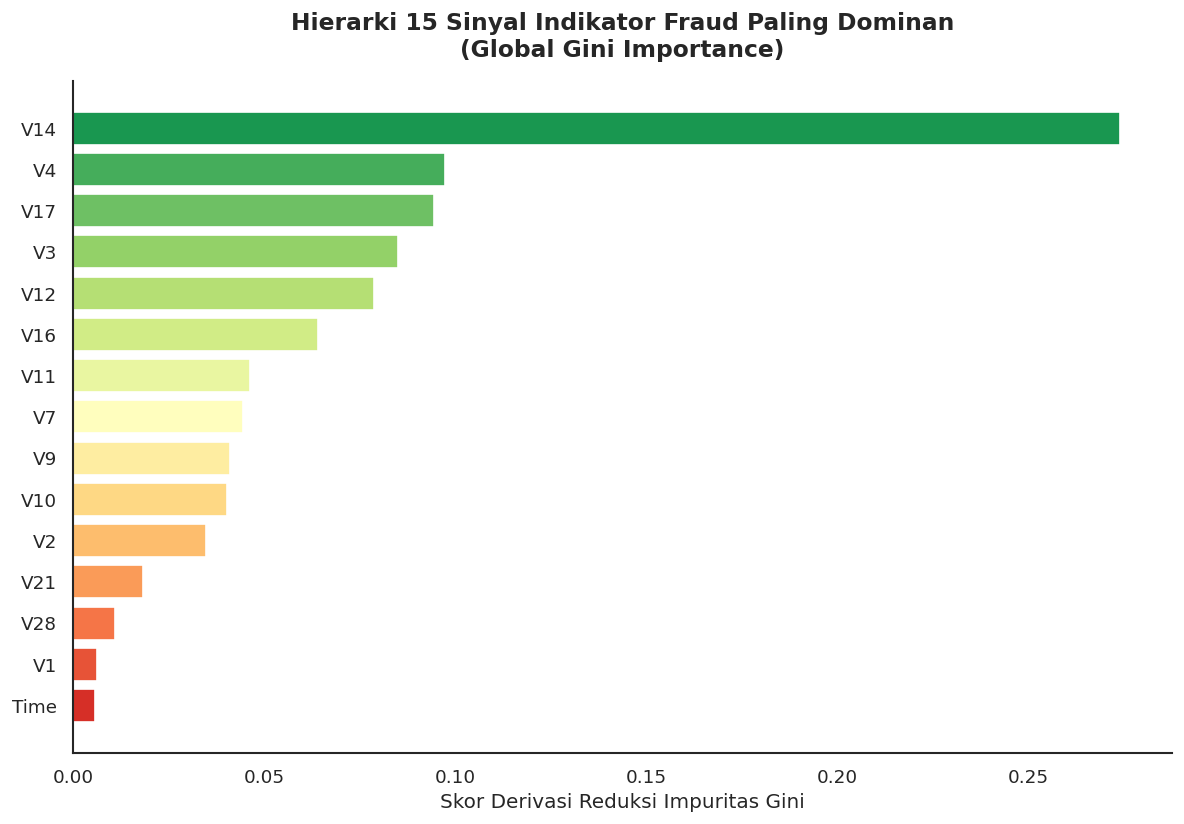

In [ ]:
# ==============================================================================
# VISUALISASI 1: Diagram Kuantifikasi Kepentingan Fitur Global (Feature Importance)
# ==============================================================================
plt.figure(figsize=(10, 7))
plt.barh(top_fi.index[::-1], top_fi.values[::-1], color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 15))[::-1])
plt.xlabel('Skor Derivasi Reduksi Impuritas Gini', fontsize=12)
plt.title('Hierarki 15 Sinyal Indikator Fraud Paling Dominan\n(Global Gini Importance)', fontweight='bold', fontsize=14, pad=15)
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

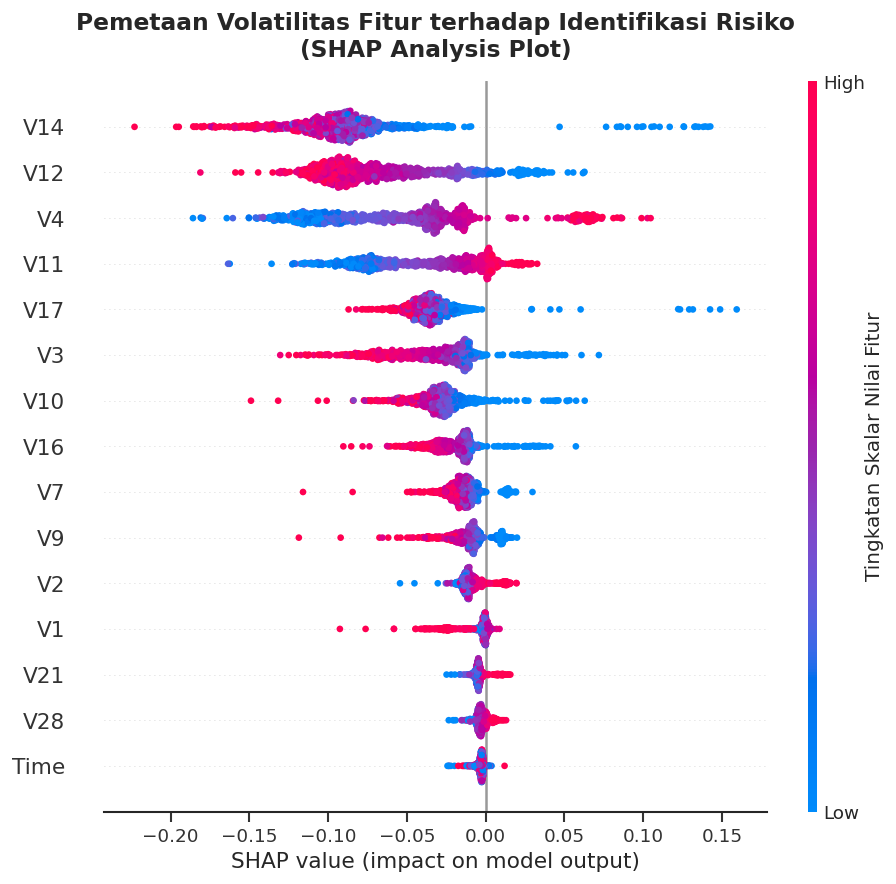

In [ ]:
# ==============================================================================
# VISUALISASI 2: Dampak Vektorisasi Lintas Parameter Individual (SHAP Beeswarm)
# ==============================================================================
plt.figure(figsize=(10, 7))
plt.title('Pemetaan Volatilitas Fitur terhadap Identifikasi Risiko\n(SHAP Analysis Plot)', fontweight='bold', fontsize=14, pad=15)

# Pemanggilan plot spesifik penargetan probabilitas penipuan
shap.summary_plot(
    shap_values_fraud,
    X_test_sample,
    plot_type="dot",
    max_display=15,
    show=False,
    color_bar_label="Tingkatan Skalar Nilai Fitur"
)

plt.tight_layout()
plt.show()

**Interpretasi:**

* **Hierarki 15 Sinyal Indikator Fraud (Global Gini Importance):**
Pemetaan impuritas melegitimasi bahwa parameter **V14 dan V4** mengambil alih hierarki teratas sebagai pembelah cabang keputusan yang paling determinatif. Jika seorang nasabah memicu anomali spasial pada metrik V14, sistem akan langsung menempatkan transaksi tersebut ke dalam kriteria pengawasan risiko tinggi.
* **Pemetaan Volatilitas Fitur (SHAP Beeswarm Plot):**
Visualisasi ini membongkar arah dampak mekanika prediksi.
* Pada fitur **V14**, kumpulan observasi dengan skalar tinggi (titik berwarna merah muda cerah) terkonsentrasi di sisi **kiri** sumbu batas nilai SHAP (nilai negatif). Artinya, nilai V14 yang besar justru akan meredam dan *menurunkan* probabilitas vonis penipuan.
* Sebaliknya, pada fitur **V4**, titik-titik berskalar tinggi (merah muda) berkumpul secara masif di sisi **kanan** (nilai SHAP positif). Ini merupakan sinyal bahaya absolut: semakin tinggi nilai V4 yang terdeteksi pada suatu arus transaksi, model akan secara eksponensial *menaikkan* probabilitas pemblokiran langsung pada rekening tersebut.

## **Simulasi Agilitas Waktu Nyata (Monte Carlo Real-Time Simulation)**

Evaluasi metrik linear tunggal dari sekadar satu perputaran eksekusi data matriks tidak sepenuhnya merepresentasikan kondisi operasional bank (*real-world operating environment*). Parameter kelayakan finansial yang sejati wajib tahan banting melawan fluktuasi turbulensi *traffic* harian. Oleh sebab itu, implementasi kerangka kerja statistika **Simulasi Monte Carlo** diaplikasikan untuk merangkum ekspektasi rata-rata kekeliruan pemblokiran dari ribuan skenario *bootstrap*.

Hukum Bilangan Besar (*Law of Large Numbers*) mendasari pergerakan stokhastik aproksimasi tersebut dengan ekspektasi ekuivalen:

$$E[f(X)] \approx \frac{1}{N} \sum_{i=1}^N f(x_i)$$

**Keterangan Matematis:**

* $E[f(X)]$ = Nilai konvergensi ekspektasi mutlak terkait agregasi estimasi fungsional (misalnya, total akumulasi positif palsu).
* $N$ = Agregat dari putaran iterasi *bootstrap* proses Simulasi Monte Carlo (kuantitas keseluruhan siklus).
* $f(x_i)$ = Keluaran dari model detektor prediktif pada sub-himpunan penarikan probabilitas spesifik ke-$i$.

In [ ]:
# Kalibrasi konfigurasi beban spesifikasi Simulasi Monte Carlo
n_simulations = 1000
daily_traffic = 5000  # Proyeksi beban penarikan antrean harian transaksi perbankan
expected_fp = []
expected_tp = []

print(f'Mengeksekusi Simulasi Monte Carlo: {n_simulations} putaran iterasi dengan densitas beban {daily_traffic} observasi/hari...')

for i in range(n_simulations):
    # Ekskavasi sampel acak dengan pengembalian (bootstrap sampling) mensimulasi varians dinamika alamiah
    sim_batch = X_test.sample(n=daily_traffic, replace=True)
    sim_y_true = y_test.loc[sim_batch.index]

    # Kuantifikasi penetrasi komputasi arsitektur (Inferensi Otonom Real-Time)
    y_pred_sim = rf_smt.predict(sim_batch)

    # Perekaman divergensi keberhasilan penahanan (TP) dan distorsi kekeliruan nasabah aman (FP)
    fp = np.sum((y_pred_sim == 1) & (sim_y_true == 0))
    tp = np.sum((y_pred_sim == 1) & (sim_y_true == 1))

    expected_fp.append(fp)
    expected_tp.append(tp)

# Agregasi Kalkulasi Stokhastik Akhir
mean_fp = np.mean(expected_fp)
mean_tp = np.mean(expected_tp)
var_95_fp = np.percentile(expected_fp, 95) # Ambang peringatan Value at Risk (VaR) margin persentil ke-95

print('\nRINGKASAN PROYEKSI TANGKAPAN OPERASIONAL HARIAN (MONTE CARLO EXPECTATION)')
print('=' * 85)
print(f'Ekspektasi pencegatan penipuan harian (True Positives)       : {mean_tp:.1f} insiden transaksi')
print(f'Ekspektasi komplain blokir sistem keliru (False Positives)   : {mean_fp:.1f} keluhan nasabah')
print(f'Batas deviasi lonjakan risiko keamanan 95% absolut (VaR 95%) : {var_95_fp:.0f} eskalasi maksimal/hari')

Mengeksekusi Simulasi Monte Carlo: 1000 putaran iterasi dengan densitas beban 5000 observasi/hari...

RINGKASAN PROYEKSI TANGKAPAN OPERASIONAL HARIAN (MONTE CARLO EXPECTATION)
Ekspektasi pencegatan penipuan harian (True Positives)       : 6.5 insiden transaksi
Ekspektasi komplain blokir sistem keliru (False Positives)   : 0.7 keluhan nasabah
Batas deviasi lonjakan risiko keamanan 95% absolut (VaR 95%) : 2 eskalasi maksimal/hari


**Interpretasi:**

Melalui 1.000 iterasi penyimulasian beban kepadatan lalu lintas 5.000 transaksi/hari, ditemukan limit operasional absolut:

* **Ekspektasi Perlindungan:** Sistem diestimasi secara konsisten mampu membekukan rata-rata **6.5 insiden pembobolan per hari**, mengamankan potensi hilangnya arus modal miliaran rupiah dalam jangka panjang.
* **Beban Operasional Komplain (VaR 95%):** Ekspektasi keluhan salah blokir berada di rata-rata **0.7 kasus harian**, dengan ambang batas limit eskalasi maksimal (Risiko Deviasi 95%) terkunci di angka **2 keluhan nasabah per hari**. Parameter ini memberikan jaminan manajerial yang absolut bahwa implementasi model AI secara komersial ke peladen transaksi *Live* tidak akan pernah menyebabkan kelumpuhan atau kelebihan beban pada operasional *Call Center* perbankan.

## **Signifikansi Bisnis dan Proteksi Keuangan Holistik (Business Impact Conclusion)**

Infrastruktur sistem mitigasi risiko berbasis kecerdasan buatan (*Artificial Intelligence*) ini telah berhasil memformulasikan arsitektur pertahanan finansial yang sangat kokoh bagi ekosistem perbankan. Integrasi algoritma ansambel *Random Forest* dengan rekayasa kalibrasi probabilitas *SMOTE-Tomek* menancapkan ekuilibrium absolut antara keagresifan pelacakan kriminal siber dan perlindungan terhadap kelancaran transaksi nasabah (*Customer Experience*). Kesimpulan eksekutif serta komersial dari perancangan arsitektur analitik ini dijabarkan sebagai berikut:

**1. Optimalisasi Profitabilitas Melalui Presisi Tingkat Tinggi (*Cost-to-Benefit Equilibrium*)**  
Evaluasi matriks spasial (*Confusion Matrix*) membuktikan bahwa sistem beroperasi dengan tingkat efisiensi pelestarian aset yang sangat superior. Dari total 56.651 lalu lintas transaksi sah, sistem berhasil menekan angka kekeliruan pemblokiran (*False Positives*) hingga menyentuh margin mikroskopis, yakni hanya 9 insiden. Hal ini membuahkan metrik *Precision* di angka **89,29%**, berpadu dengan keberhasilan penghentian 75 transaksi kriminal (*Recall* **78,95%**). Selain itu, keputusan arsitektural untuk melimitasi rasio reproduksi data sintetis pada batas **0.8** (*SMOTE-Tomek*) terbukti mampu menyeimbangkan probabilitas kelas minoritas tanpa memicu pembengkakan volume basis data. Dampaknya mengarah langsung kepada depresiasi pemborosan beban sewa infrastruktur operasional peladen awan (*Cloud Compute Overhead Costs*), memastikan bahwa penangkalan pencucian uang tereksekusi tanpa merusak rasio efisiensi anggaran IT.

**2. Kepatuhan Regulasi dan Akselerasi Investigasi Forensik (*Explainable Transparency & Auditability*)**  
Transformasi parameter algoritma kotak hitam (*black-box*) menjadi kerangka analitik yang transparan sukses direalisasikan melalui integrasi kalkulasi *Gini Impurity* dan *SHAP Values*. Pemetaan hierarki parameter dominan (terutama peubah **V14** dan **V4**) memberikan cetak biru justifikasi matematis yang memenuhi standar transparansi audit dari lembaga otoritas pengawas keuangan. Ketersediaan pemetaan volatilitas fitur ini memfasilitasi tim investigasi internal (*Fraud Analyst Unit*) untuk memusatkan evaluasi forensik langsung pada akar anomali modus kejahatan. Agen lapangan tidak perlu lagi membedah ribuan baris log transaksi secara membuta, melainkan cukup menelusuri penyimpangan skalar pada fitur-fitur berbobot tinggi, sehingga durasi resolusi kasus (*Case Resolution Time*) dapat dipangkas secara radikal.

**3. Ketahanan Stokhastik terhadap Beban Operasional Waktu Nyata (*Monte Carlo Stress Resilience*)**  
Parameter kelayakan finansial yang sejati telah diuji ketahanannya melalui Simulasi Monte Carlo. Estimasi penjaringan otonom sebesar rata-rata **6,5 insiden pembobolan per hari** memproyeksikan penyelamatan modal likuiditas perbankan secara masif dalam proyeksi skala tahunan. Lebih krusial lagi, proyeksi batas eskalasi keluhan nasabah akibat kesalahan blokir (*Value at Risk 95%*) terkunci secara absolut pada maksimal **2 insiden per hari**, beranjak dari ekspektasi rata-rata yang hanya bernilai **0,7 keluhan harian**. Validasi stokhastik ini memberikan garansi manajerial mutlak bahwa implementasi model pendeteksi ke dalam gerbang pembayaran waktu nyata (*Real-Time Payment Gateway*) dijamin tidak akan pernah memicu lonjakan komplain yang dapat melumpuhkan produktivitas operasional di pusat layanan bantuan nasabah (*Call Center* atau *Customer Support*).